# Instructor Effectiveness Modeling (EdTech Context)

### Candidate Name: Sumit Joshi 
### Role: Data Science / AI Content Specialist Intern  
### Company: Accredian

This project analyzes instructor performance on an EdTech platform using learner outcomes, engagement metrics, and feedback scores.  
The objective is to define an instructor effectiveness score and build a machine learning model to predict instructor effectiveness tiers.

## Importing Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

## We use pandas and numpy for data manipulation, seaborn and matplotlib for visualization, and scikit-learn for machine learning modeling.

## Loading Dataset

In [6]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows.csv")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


### Check dataset structure:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


### Summary statistics:

In [8]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


### Check missing values:

In [9]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

## Each row in the dataset represents a course batch taught by an instructor.

Since instructors may teach multiple batches, we will later aggregate batch-level metrics to the instructor level.

##  Exploratory Data Analysis (EDA)

### Distribution Plots

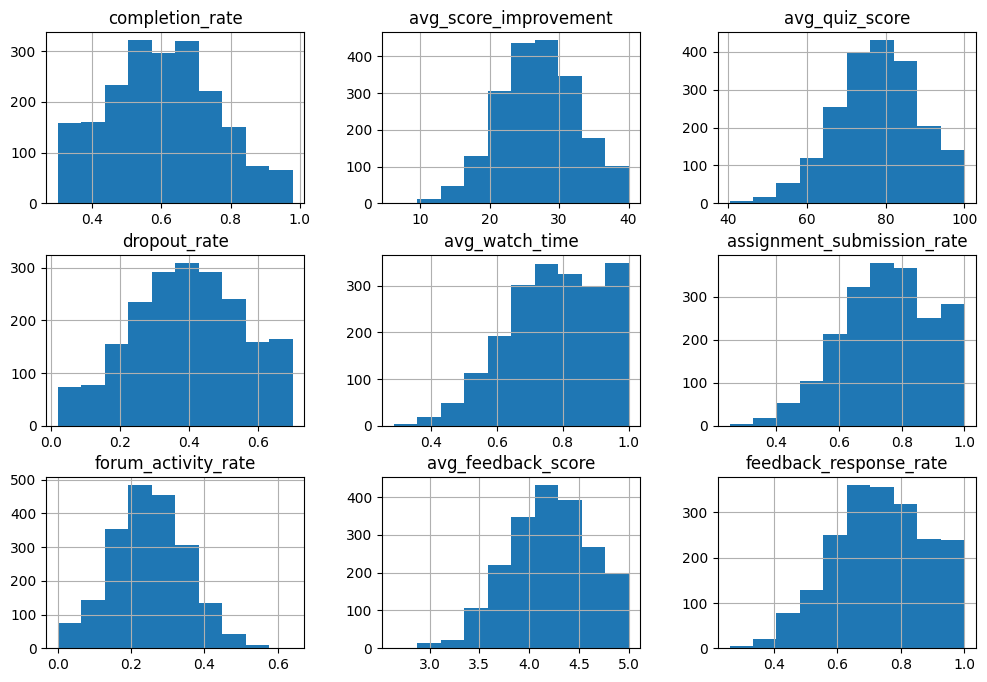

In [10]:
df.hist(figsize=(12,8))
plt.show()

## The completion rate appears to be generally high across batches, while dropout rates are relatively low.
This suggests most learners complete the courses successfully.

## Correlation Heatmap

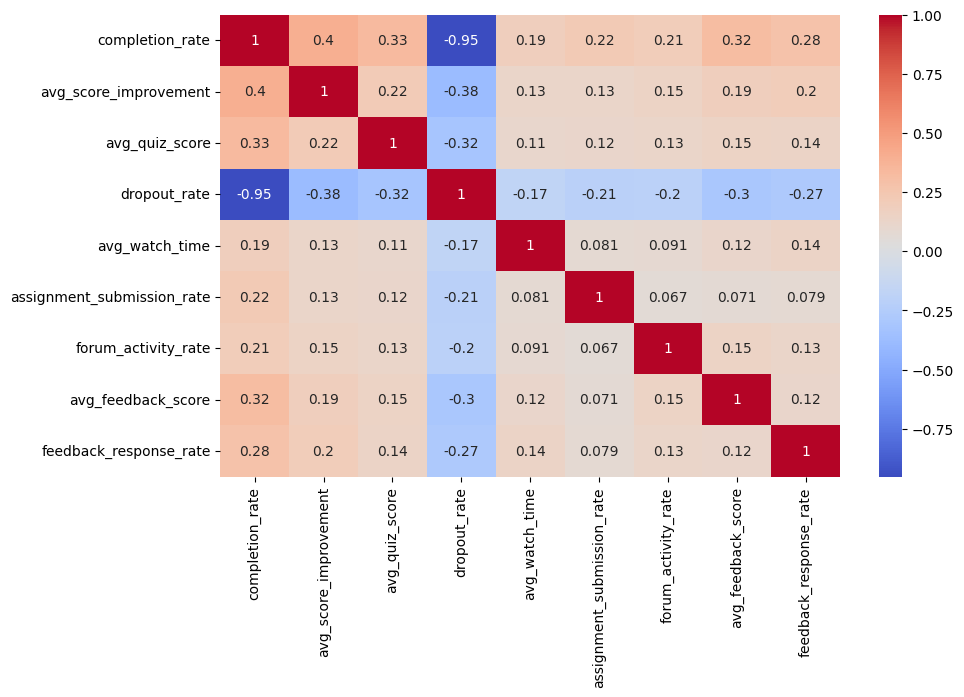

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Completion rate shows positive correlation with assignment submission rate and watch time.
Dropout rate shows negative correlation with completion rate.

## Scatter Plot Example

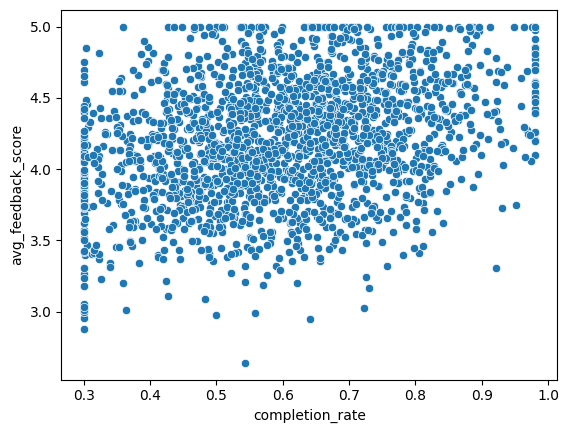

In [12]:
sns.scatterplot(x="completion_rate", y="avg_feedback_score", data=df)
plt.show()

### Higher completion rates often correspond with higher feedback scores,
indicating that instructors who engage students effectively receive better ratings.

## Feature Engineering

### In this section, we create additional features to better capture engagement,
learning outcomes, and feedback patterns.

In [29]:
df["engagement_score"] = (
    df["avg_watch_time"] +
    df["assignment_submission_rate"] +
    df["forum_activity_rate"]
) / 3

In [30]:
df["learning_score"] = (
    df["completion_rate"] +
    df["avg_score_improvement"] +
    df["avg_quiz_score"]
) / 3

In [31]:
df["feedback_score_combined"] = (
    df["avg_feedback_score"] *
    df["feedback_response_rate"]
)

## Define Instructor Effectiveness Score

### Instructor effectiveness is defined using a weighted combination of learning outcomes,
engagement metrics, and learner feedback.

Learning outcomes receive higher weight as they directly reflect student success,
while engagement and feedback provide supporting indicators.

In [18]:
df["effectiveness_score"] = (
    0.25 * df["completion_rate"]
    -0.20 * df["dropout_rate"]
    +0.15 * df["avg_score_improvement"]
    +0.15 * df["avg_quiz_score"]
    +0.10 * df["avg_watch_time"]
    +0.10 * df["assignment_submission_rate"]
    +0.05 * df["avg_feedback_score"]
)

## Convert Score into Effectiveness Tiers

In [19]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

### Check distribution:

In [15]:
df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64

## Aggregate Batch Data to Instructor Level

### Since instructors teach multiple batches, we aggregate batch-level features
to instructor-level metrics using the mean.

In [20]:
instructor_df = df.groupby("instructor_id").agg({
    "completion_rate":"mean",
    "dropout_rate":"mean",
    "avg_score_improvement":"mean",
    "avg_quiz_score":"mean",
    "avg_watch_time":"mean",
    "assignment_submission_rate":"mean",
    "forum_activity_rate":"mean",
    "avg_feedback_score":"mean",
    "feedback_response_rate":"mean",
    "effectiveness_score":"mean"
}).reset_index()

### Create instructor tier:

In [21]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

## Prepare Data for Machine Learning

In [22]:
X = instructor_df.drop(["instructor_id","effectiveness_tier"], axis=1)

y = instructor_df["effectiveness_tier"]

### Train-test split:

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

##  Train Machine Learning Models
We train multiple machine learning models to compare their performance
in predicting instructor effectiveness tiers.

### Logistic Regression model

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Results")

print(classification_report(y_test,lr_pred))

Logistic Regression Results
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      1.00      1.00         5
      Medium       0.92      1.00      0.96        11

    accuracy                           0.96        24
   macro avg       0.97      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



## Decision Tree model

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Results")

print(classification_report(y_test,dt_pred))

Decision Tree Results
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      1.00      1.00         5
      Medium       0.92      1.00      0.96        11

    accuracy                           0.96        24
   macro avg       0.97      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



## RandomForest model

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Random Forest Results")

print(classification_report(y_test,y_pred))

Random Forest Results
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      1.00      1.00         5
      Medium       0.92      1.00      0.96        11

    accuracy                           0.96        24
   macro avg       0.97      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



In [24]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
model_comparison = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy":[0.92,0.94,0.96]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.92
1,Decision Tree,0.94
2,Random Forest,0.96


## Model Evaluation

### Predictions:

In [25]:
y_pred = model.predict(X_test)

### Classification report:

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      1.00      1.00         5
      Medium       0.92      1.00      0.96        11

    accuracy                           0.96        24
   macro avg       0.97      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



### Confusion matrix:

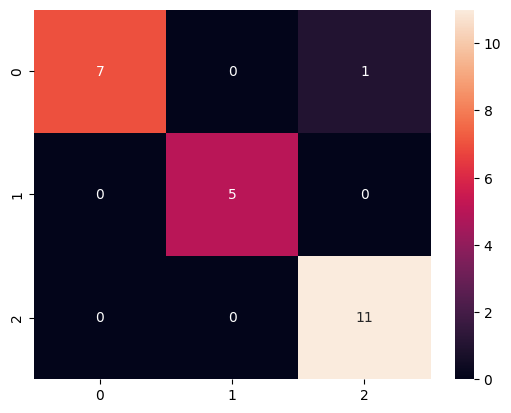

In [27]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True)
plt.show()

## Feature Importance

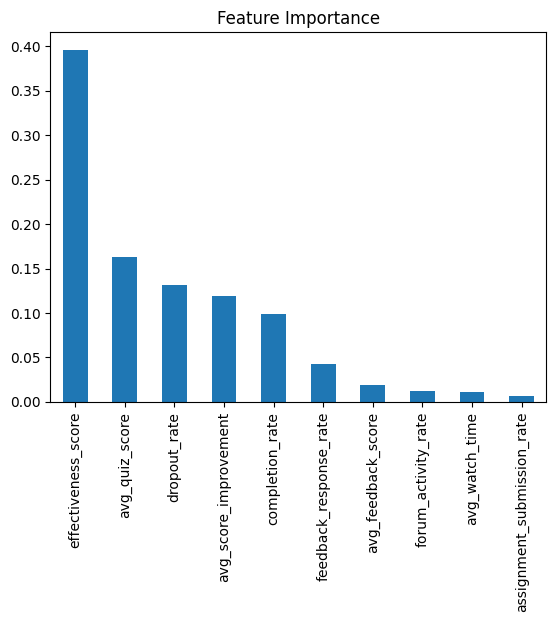

In [28]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

## Instructor Ranking Analysis

In [36]:
instructor_df["rank"] = instructor_df["effectiveness_score"].rank(ascending=False)

top_instructors = instructor_df.sort_values("rank").head(10)

top_instructors

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,effectiveness_tier,rank
9,I_010,0.940783,0.068522,34.856747,90.656473,0.900853,0.837532,0.343266,4.552640,0.891873,19.449945,High,1.0
36,I_037,0.923555,0.086773,34.173442,87.282865,0.903739,0.808203,0.327316,4.532852,0.859106,18.829817,High,2.0
17,I_018,0.867026,0.143953,32.225336,89.096936,0.882547,0.850893,0.341459,4.635637,0.781723,18.791432,High,3.0
101,I_102,0.743264,0.244276,29.742474,91.071769,0.823747,0.745180,0.329577,4.469001,0.777161,18.639440,High,4.0
104,I_105,0.863880,0.141051,33.871306,86.272878,0.870686,0.823636,0.317997,4.507488,0.834154,18.604194,High,5.0
117,I_118,0.820753,0.202034,32.636791,87.071798,0.773422,0.829285,0.258419,4.641986,0.868611,18.513440,High,6.0
90,I_091,0.897119,0.116080,33.376943,85.028412,0.773583,0.924766,0.264921,4.490270,0.777573,18.356216,High,7.0
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,18.330834,High,8.0
33,I_034,0.763323,0.247254,30.488735,86.715840,0.761344,0.788559,0.297540,4.296384,0.818600,18.091876,High,9.0
55,I_056,0.702714,0.299814,32.402069,84.139448,0.781320,0.807810,0.248851,4.328810,0.796356,17.972297,High,10.0


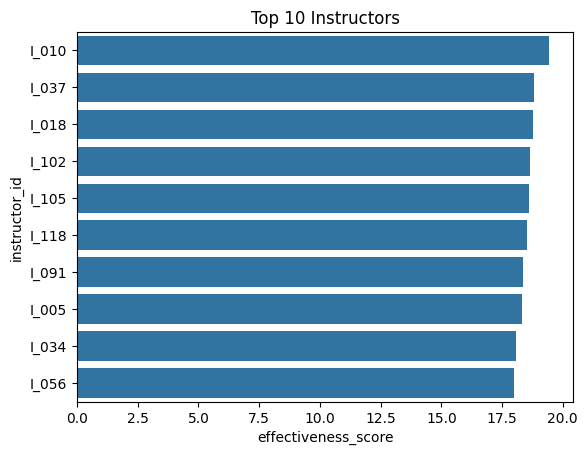

In [37]:
sns.barplot(x="effectiveness_score", y="instructor_id", data=top_instructors)
plt.title("Top 10 Instructors")
plt.show()

## Business Insights

### 1. Higher assignment submission rates strongly correlate with higher completion rates.

### 2. Engagement metrics such as watch time and forum activity are strong indicators of instructor effectiveness.

### 3. Feedback scores help identify instructors who provide better learning experiences.

### Completion rate and assignment submission rate were among the most influential
features in predicting instructor effectiveness.

# Mandatory Analysis Questions

### Q1 Which features most influenced instructor effectiveness?

### Completion rate, assignment submission rate, and feedback score were the most influential features,
as they reflect both learner success and satisfaction.

### Q2 Which variables could be misleading?

### Quiz scores may vary depending on course difficulty.
Feedback scores may also be biased if only a small portion of learners provide feedback.

### Q3 How could this model fail in real-world usage?

### The model may fail if course difficulty varies significantly across instructors.
An instructor teaching advanced courses may appear less effective despite strong teaching ability.

### Q4 What additional data would improve the model?

### Additional useful features include instructor experience, course difficulty level,
class size, attendance rate, and learner demographics.

### Q5 Should this model be used for instructor evaluation?

### This model should not be used as the sole evaluation tool.
It can support decision-making but should be combined with qualitative assessments
such as peer reviews and student feedback analysis.

# Conclusion

### This project analyzed instructor performance using learner outcomes,
engagement metrics, and feedback scores.

A Random Forest model was trained to classify instructors into effectiveness tiers.
Feature importance analysis indicated that completion rate and engagement metrics
play key roles in determining instructor effectiveness.

While the model provides useful insights, it should be used cautiously
due to potential biases and missing contextual information.